In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.binning import add_cns_loc, group_bins, sum_cns
from cns.display.plot import plot_lines, fig_lines
from cns.data_utils import  load_filter_samples, load_filter_bins, get_cns_for_type

c:\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
samples = load_filter_samples()
samples["PCAWG"]["TCGA_type"].value_counts()[:6]

TCGA_type
LIRI    250
PACA    233
PBCA    230
BRCA    211
PRAD    158
OV      110
Name: count, dtype: int64

In [4]:
cns = load_filter_bins(samples, "10MB")

In [5]:
get_cns_for_type(cns["PCAWG"], samples["PCAWG"], "LUAD").head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
0,SP50827,chr1,0,10127953,1.0,0.000000,10127953,5063976,5063976,1.000000
1,SP50827,chr1,10127953,20255906,1.0,0.000000,10127953,15191929,15191929,1.000000
2,SP50827,chr1,20255906,30383859,1.0,0.288645,10127953,25319882,25319882,1.288645
3,SP50827,chr1,30383859,40511811,1.0,0.672510,10127952,35447835,35447835,1.672510
4,SP50827,chr1,40511811,50639764,1.0,0.564178,10127953,45575787,45575787,1.564178


In [6]:
luad_dict = { k : get_cns_for_type(cns[k], samples[k], "LUAD") for k in cns.keys() }
lusc_dict = { k : get_cns_for_type(cns[k], samples[k], "LUSC") for k in cns.keys() }
means_single = [group_bins(dataset) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [group_bins(dataset) for dataset in [luad_all, lusc_all]]

In [7]:
luad_dict.keys()

dict_keys(['PCAWG', 'TRACERx', 'TCGA'])

In [8]:
means_single[0].head()

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,5063976,chr1,0,10127953,5063976,10127953,2.027833,1.058715,3.086548
1,15191929,chr1,10127953,20255906,15191929,10127953,1.981953,1.037484,3.019437
2,25319882,chr1,20255906,30383859,25319882,10127953,1.922425,1.073997,2.996421
3,35447835,chr1,30383859,40511811,35447835,10127952,1.950432,1.190850,3.141282
4,45575787,chr1,40511811,50639764,45575787,10127953,1.945178,1.191856,3.137034


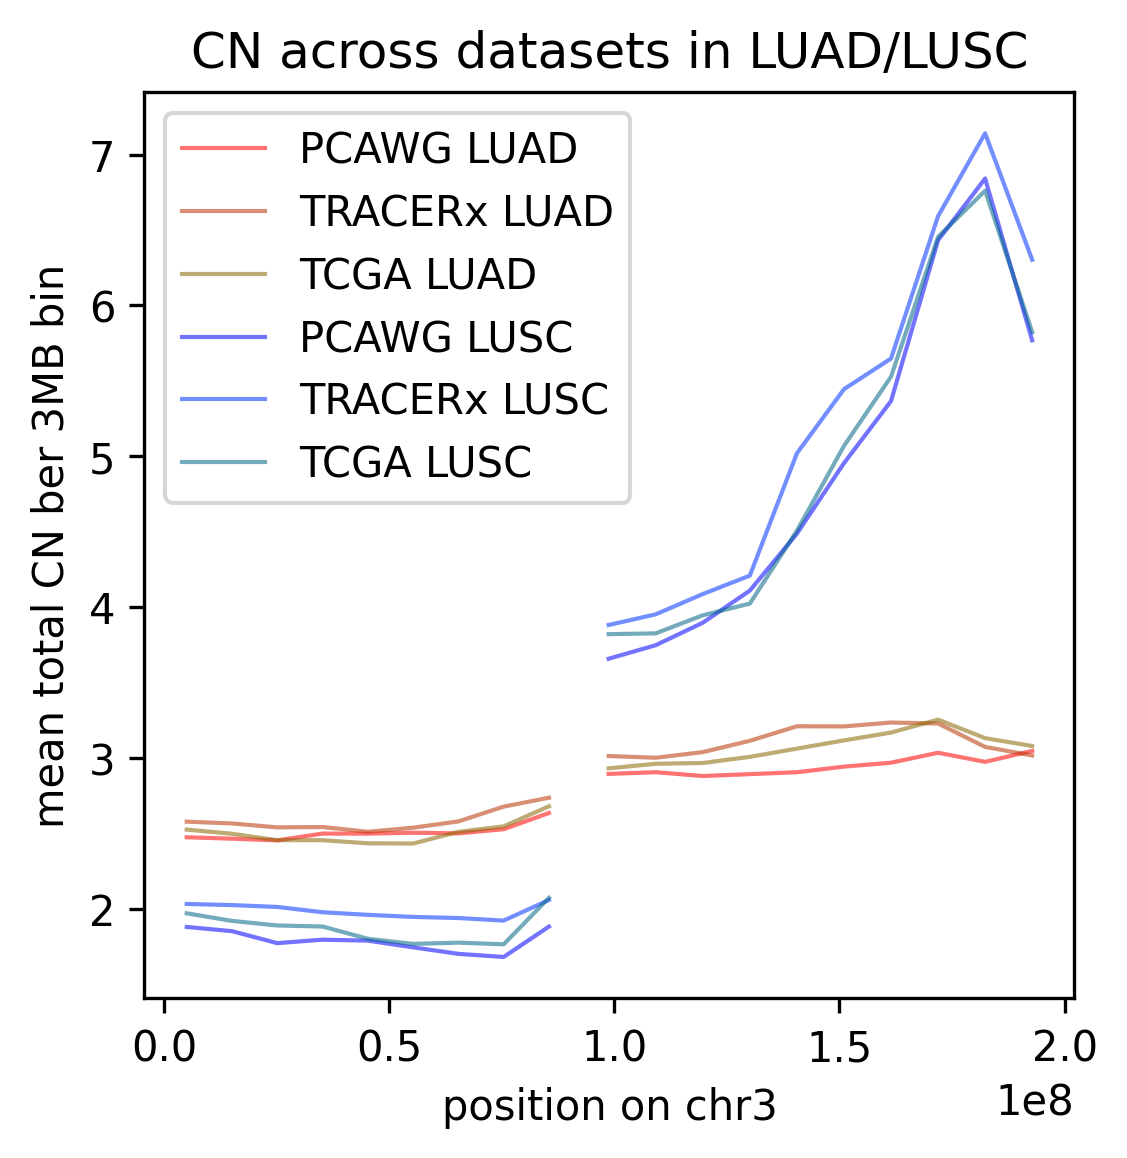

In [9]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"], dpi=300, chrom="chr3")
ax.set_ylabel("mean total CN ber 3MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')

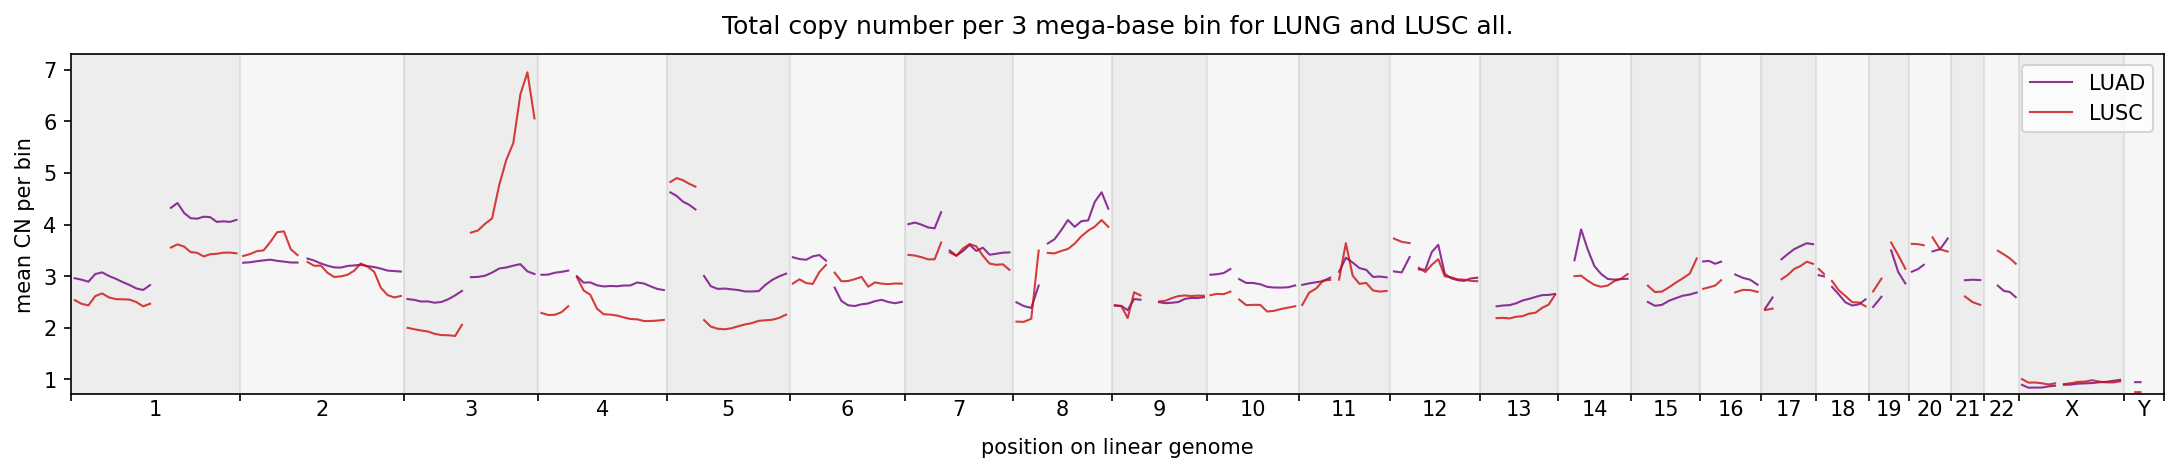

In [10]:
fig, ax = fig_lines(means_all, ["LUAD", "LUSC"], column="total_cn", dpi=150)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC all.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_all.pdf", bbox_inches='tight')

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

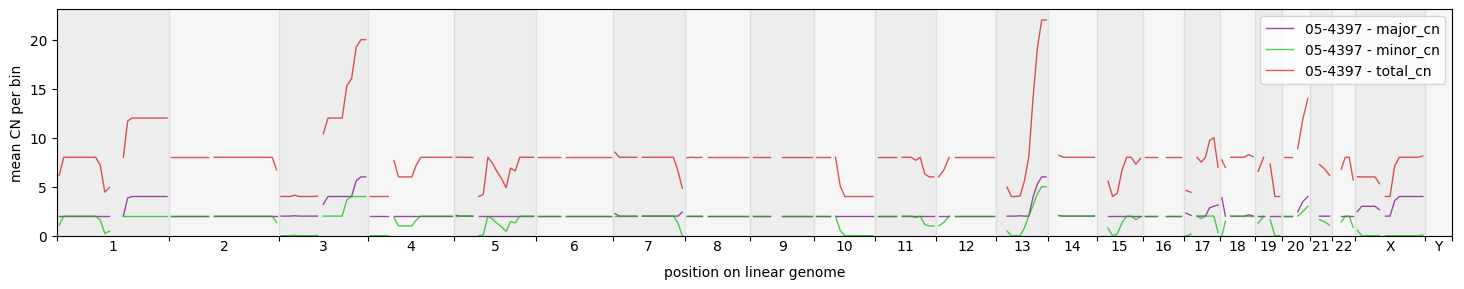

In [11]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUAD'").index[9:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig_lines(groups, shorten)

(0.0, 10.0)

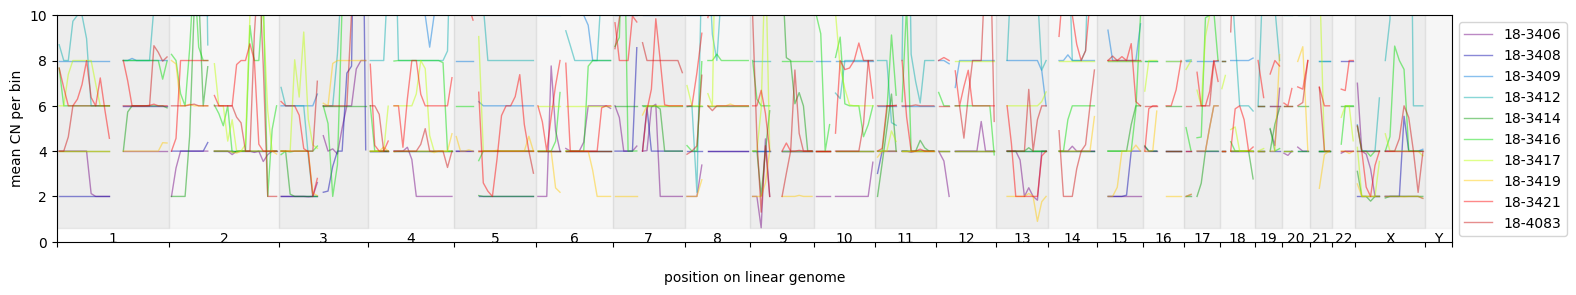

In [12]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUSC'").index[:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig, ax = fig_lines(groups, shorten, column="total_cn");
ax.set_ylim(0,10)

In [13]:
cosmic_df = load_filter_bins(samples, "COSMIC")

In [14]:
cosmic_group = group_bins(cosmic_df["PCAWG"])
cosmic_group.head()

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,2200845,chr1,2160133,2241558,2200845,81425,1.395277,0.842431,2.237708
1,2491949,chr1,2487077,2496821,2491949,9744,1.396825,0.842431,2.239257
2,3170458,chr1,2985731,3355185,3170458,369454,1.384824,0.836624,2.221448
3,6255388,chr1,6241328,6269449,6255388,28121,1.380178,0.827720,2.207898
4,7337574,chr1,6845383,7829766,7337574,984383,1.371274,0.823461,2.194735


In [15]:
from cns.data_utils import load_COSMIC

cosmic_genes = load_COSMIC()
cosmic_genes.head()

,gene,chrom,start,end
0,SKI,chr1,2160133,2241558
1,TNFRSF14,chr1,2487077,2496821
2,PRDM16,chr1,2985731,3355185
3,RPL22,chr1,6241328,6269449
4,CAMTA1,chr1,6845383,7829766


In [16]:
k = "PCAWG"
cosmic_lusc_group = group_bins(get_cns_for_type(cosmic_df[k], samples[k], "LUSC"))
cosmic_lusc_group = cosmic_lusc_group.merge(cosmic_genes, on=["chrom", "start", "end"])
cosmic_luad_group = group_bins(get_cns_for_type(cosmic_df[k], samples[k], "LUAD"))
cosmic_luad_group = cosmic_luad_group.merge(cosmic_genes, on=["chrom", "start", "end"])

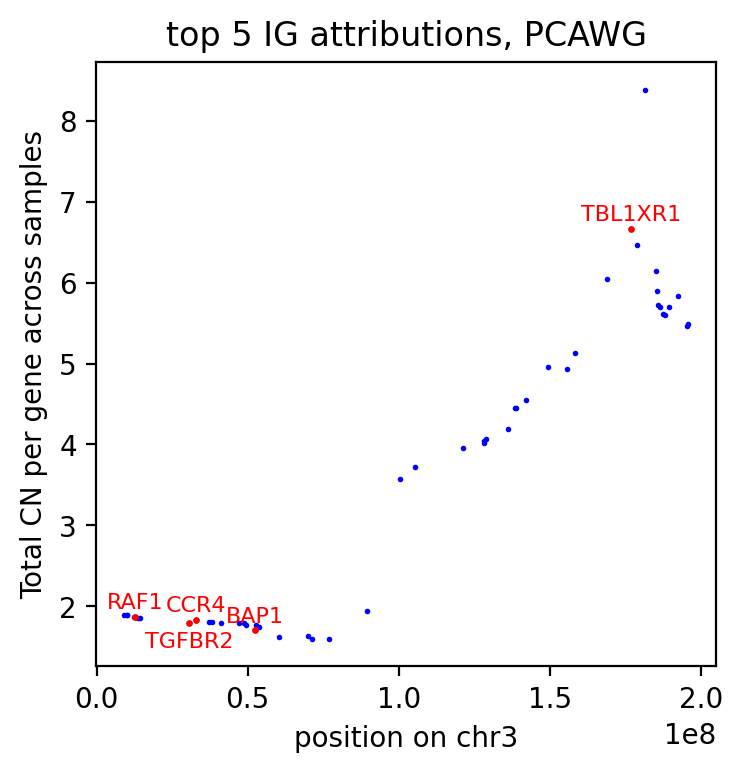

In [17]:
from cns.display.plot import fig_dots


fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn", dpi=200)

genes = ['TGFBR2', 'CCR4', 'BAP1', 'RAF1', 'TBL1XR1']

for i, row in cosmic_lusc_group.iterrows():
    if row['gene'] in genes:
        plt.scatter(row['mid'], row['total_cn'], color='red', s=2)
        offset = -.3 if row['gene'] in ['TGFBR2'] else 0.1
        text = f"{row['gene']}"
        plt.text(row['mid'], row['total_cn'] + offset, text, color="red", size=8, ha='center')

ax.set_ylabel("Total CN per gene across samples")
plt.title("top 5 IG attributions, PCAWG")

plt.savefig("../../out/fig_COSMIC_genes_IG_att.pdf", bbox_inches='tight')
plt.show()

In [20]:
chrom_3 = cosmic_lusc_group.query("chrom == 'chr3'")
chrom_3.loc[140:158]

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn,gene
140,613657559,chr3,121150277,121264853,121207565,114576,2.702128,1.255319,3.957447,POLQ
141,620655142,chr3,128198269,128212028,128205148,13759,2.787234,1.255319,4.042553,GATA2
142,620819361,chr3,128338816,128399918,128369367,61102,2.787234,1.234043,4.021277,RPN1
143,621345539,chr3,128888326,128902765,128895545,14439,2.808511,1.255319,4.063830,CNBP
144,628713142,chr3,136055076,136471220,136263148,416144,2.808511,1.382979,4.191489,STAG1
145,630913313,chr3,138372859,138553780,138463319,180921,2.978723,1.468085,4.446809,PIK3CB
146,631114517,chr3,138663065,138665982,138664523,2917,2.978723,1.468085,4.446809,FOXL2
147,634682866,chr3,142168076,142297668,142232872,129592,3.106383,1.446809,4.553191,ATR
148,641794755,chr3,149235021,149454501,149344761,219480,3.446809,1.510638,4.957447,WWTR1
149,648075063,chr3,155588324,155661815,155625069,73491,3.404255,1.531915,4.936170,GMPS


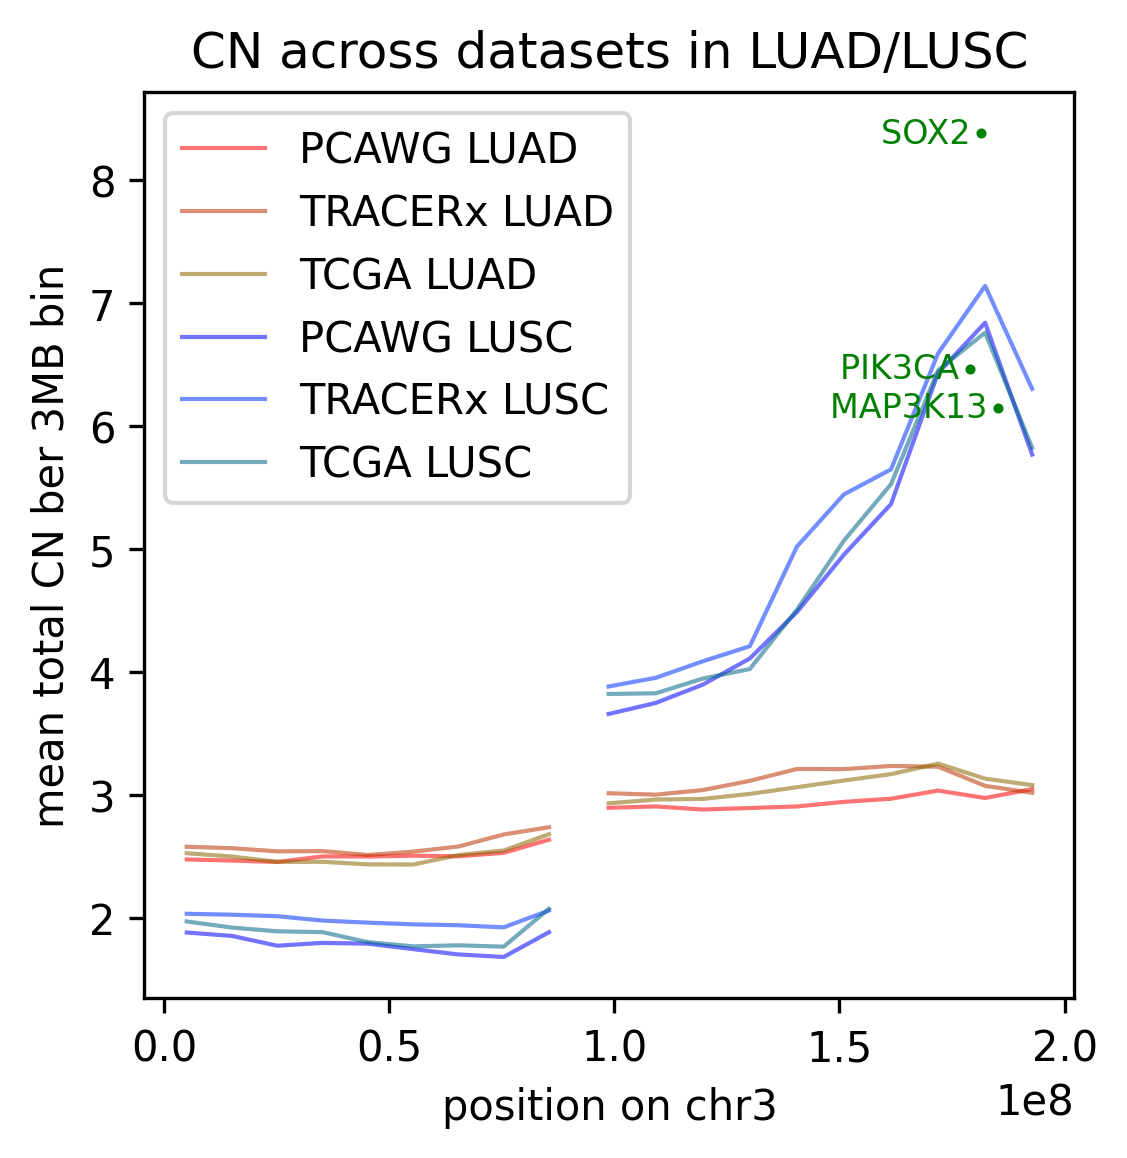

In [19]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"], dpi=300, chrom="chr3")
ax.set_ylabel("mean total CN ber 3MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')

for i, row in cosmic_lusc_group.iterrows():
    if row['gene'] in ["PIK3CA", "SOX2", "MAP3K13"]:
        plt.scatter(row['mid'], row['total_cn'], color='green', s=2)
        offset = 0
        text = f"{row['gene']} "
        plt.text(row['mid'], row['total_cn'] + offset, text, color="green", size=8, ha='right', va='center')

plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')
